# Feed Forward Neural Network con TensorFlow

En una **feed forward neural network** (FFNN) la informacion fluye en una sola direccion: desde la capa de entrada, pasando por las capas ocultas, hasta la capa de salida, sin ciclos ni retroalimentacion.


## 1. Importo librerias

Importamos TensorFlow, Keras (API de alto nivel incluida en TF), NumPy y Matplotlib para visualizacion.

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

tf.__version__

'2.20.0'

## 2. Carga de set de datos y preprocesamiento de este

Set de datos de MSINT.

**Preprocesamiento:**
1. **Aplanar** las imagenes de (28, 28) a (784,) para poder pasarlas por capas densas
2. **Normalizar** los valores de pixel de [0, 255] a [0, 1] para facilitar el entrenamiento
3. **One-hot encoding** de las etiquetas: convertir el entero (ej: `3`) en un vector binario (ej: `[0,0,0,1,0,0,0,0,0,0]`)

In [15]:
# Carga del set de datos

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# 1. Aplanar datos para las entradas: (N, 28, 28) -> (N, 784)

x_train = x_train.reshape(-1, 28 * 28)
x_test  = x_test.reshape(-1, 28 * 28)

# 2. Normalizar a 0, 1

x_train = x_train.astype("float32") / 255.0 # 255 para normalizar
x_test  = x_test.astype("float32")  / 255.0 # 255 para normalizar

# 3. One-hot encoding: es parecido a pasar datos cualitativos a cuantitavos, ver vídeo de código máquina de obsidian

num_classes = 10
y_train_ohe = keras.utils.to_categorical(y_train, num_classes) # to categorical: ver documentación
y_test_ohe  = keras.utils.to_categorical(y_test,  num_classes)

## 3. Visualización del set de datos

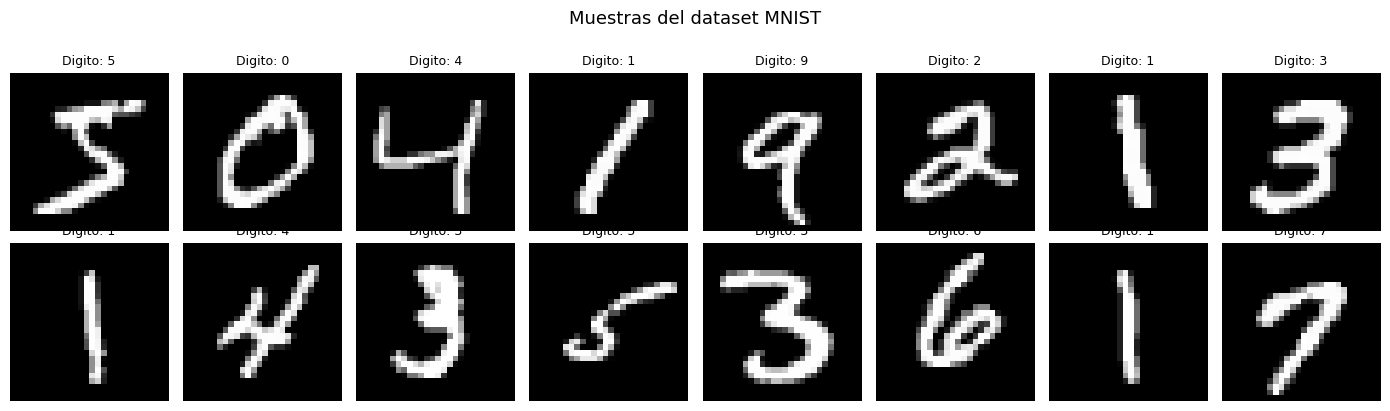

In [16]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = x_train[i].reshape(28, 28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Digito: {y_train[i]}", fontsize=9)
    ax.axis("off")
plt.suptitle("Muestras del dataset MNIST", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Arquitectura de la red

Entrada 784 neuronas -> 3 capas ocultas -> 10 clases de salida


In [17]:
def construir_modelo(input_dim=784, num_clases=10):
    modelo = keras.Sequential([
        # Capa de entrada
        layers.Input(shape=(input_dim,)),

        # Capa oculta 1
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),

        # Capa oculta 2
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),

        # Capa oculta 3
        layers.Dense(64, activation="relu"),

        # Capa de salida
        layers.Dense(num_clases, activation="softmax"),
    ], name="ffnn_mnist")

    return modelo

modelo = construir_modelo()

In [18]:
modelo.summary()

Model: "ffnn_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compilacion del modelo


In [20]:
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## 6. Entrenamiento

Cambia mucho respecto a PyTorch, sobre esto investigar un poco más las diferentes maneras de entrenar una red neuronal.

In [21]:
early_stopping = keras.callbacks.EarlyStopping( # https://keras.io/api/callbacks/early_stopping/
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

historial = modelo.fit(
    x_train, y_train_ohe,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8759 - loss: 0.4094 - val_accuracy: 0.9628 - val_loss: 0.1232
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9475 - loss: 0.1712 - val_accuracy: 0.9717 - val_loss: 0.0947
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9615 - loss: 0.1265 - val_accuracy: 0.9758 - val_loss: 0.0830
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9674 - loss: 0.1056 - val_accuracy: 0.9760 - val_loss: 0.0733
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9732 - loss: 0.0873 - val_accuracy: 0.9772 - val_loss: 0.0725
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9755 - loss: 0.0762 - val_accuracy: 0.9825 - val_loss: 0.0612
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9778 - loss: 0.0701 - val_accuracy: 0.9810 - val_loss: 0.0717
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9795 - loss: 0.0648 - val_accura

## 7. Aprendizaje y perdida

Acá no use las helper_functions.py de zerotomastery, me ayude con Gemini.

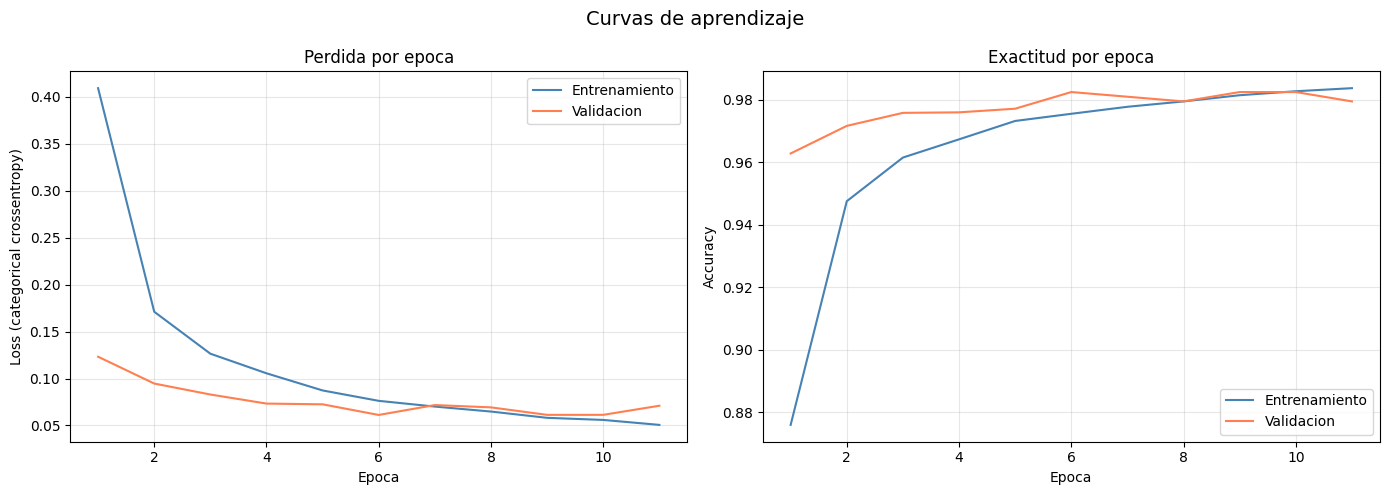

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epocas = range(1, len(historial.history["loss"]) + 1)

# Perdida
ax1.plot(epocas, historial.history["loss"],     label="Entrenamiento", color="steelblue")
ax1.plot(epocas, historial.history["val_loss"], label="Validacion",    color="coral")
ax1.set_title("Perdida por epoca")
ax1.set_xlabel("Epoca")
ax1.set_ylabel("Loss (categorical crossentropy)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Exactitud
ax2.plot(epocas, historial.history["accuracy"],     label="Entrenamiento", color="steelblue")
ax2.plot(epocas, historial.history["val_accuracy"], label="Validacion",    color="coral")
ax2.set_title("Exactitud por epoca")
ax2.set_xlabel("Epoca")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Curvas de aprendizaje", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Evaluacion en el conjunto de prueba


In [23]:
loss_test, acc_test = modelo.evaluate(x_test, y_test_ohe, verbose=0)
print(f"Loss en test:     {loss_test:.4f}")
print(f"Accuracy en test: {acc_test*100:.2f}%")

Loss en test:     0.0782
Accuracy en test: 97.67%


## 9. Predicciones

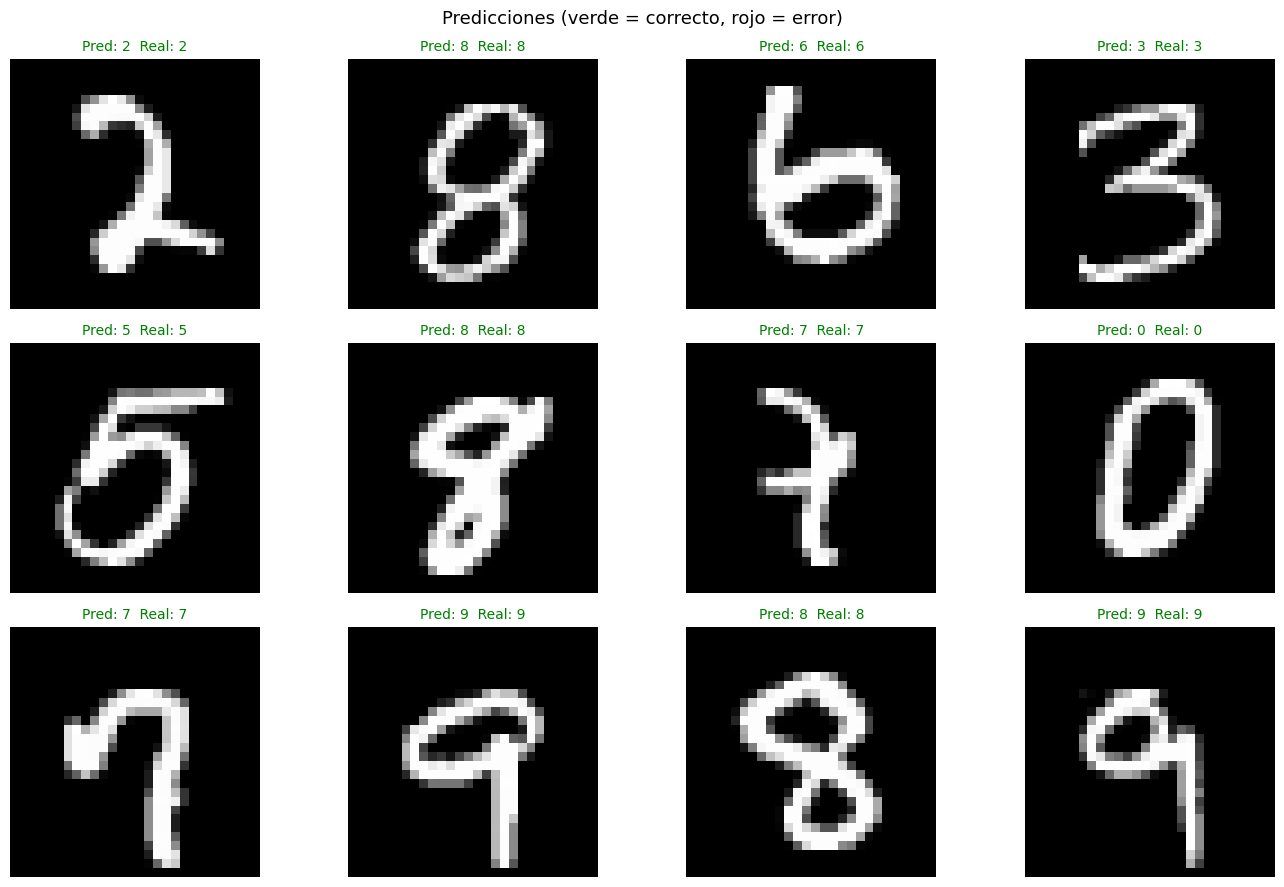

In [24]:
# Predicciones sobre el conjunto de test
probs = modelo.predict(x_test, verbose=0)
y_pred = np.argmax(probs, axis=1)

# Mostrar 12 ejemplos aleatorios
indices = np.random.choice(len(x_test), 12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for i, ax in zip(indices, axes.flat):
    img = x_test[i].reshape(28, 28)
    ax.imshow(img, cmap="gray")
    prediccion = y_pred[i]
    real = y_test[i]
    color = "green" if prediccion == real else "red"
    ax.set_title(f"Pred: {prediccion}  Real: {real}", color=color, fontsize=10)
    ax.axis("off")

plt.suptitle("Predicciones (verde = correcto, rojo = error)", fontsize=13)
plt.tight_layout()
plt.show()

## 12. Guardado del modelo

Extra al curso, lo guardo para el próximo a realizar de despliegue de modelos.

In [13]:
# Guardar en formato .keras (recomendado)
modelo.save("ffnn_mnist.keras")
print("Modelo guardado como 'ffnn_mnist.keras'")

# Para cargarlo luego:
# modelo_cargado = keras.models.load_model("ffnn_mnist.keras")

Modelo guardado como 'ffnn_mnist.keras'
